In [1]:
import importlib
import numpy as np
import sklearn
from matplotlib import pyplot as plt
from os.path import join
import os
import seaborn as sns
from torchvision.ops.misc import interpolate
from tqdm.notebook import tqdm

#### Custum libraries
import lib.algos_maxRSA as max_rsa
import lib.utils_RSA as rsa
import lib.utils_CKA as cka
from lib.algos import *
from representational_screening import RDM1

importlib.reload(rsa)
importlib.reload(cka)
importlib.reload(max_rsa)

<module 'lib.algos_maxRSA' from '/home/alban/projects/Gen-then-Screen/lib/algos_maxRSA.py'>

In [14]:

#### Load activations - same as in representational_screening.py script
model1 = 'places365'
model2 = 'imagenet'

path2activations = 'data/activations/%s'
models = [model1, model2]

imagelists = {}
activations = {}
for model in models:
    with open(join(path2activations%model, 'imagepaths.txt'), 'r') as f:
        imagelists[model] = [line.strip() for line in f.readlines()]
    activations[model] = np.load(join(path2activations % model, 'activations.npy'))

### check if images were shown in the same order
assert imagelists[models[0]] == imagelists[models[1]]
imagelist = imagelists[models[0]] # since they are the same, only consider one list


#### Normalize vectors to bias towards colinearity measuer
print('Normalizing activations - make sure the activation arrays have the shape (nb_images, nb_activations)')
for model in models:
    activations[model] = activations[model].reshape(activations[model].shape[0], activations[model].shape[1])
    norms = np.linalg.norm(activations[model], axis=1, keepdims=True)
    activations[model] = activations[model]/norms # normalization


#### check if each category has the same number of exemplars and list all categories in listcats
print('checking if each category has the same number of exemplars and saving category names')
count = 0
cat = ''
listcat = list()
for i, imgp in enumerate(imagelist):
    current_cat = imgp.split('/')[-2] # assumes the dataset as subdirectories for each category
    if i == 0:
        cat = current_cat
        listcat.append(current_cat)
    if cat != current_cat:
        cat = current_cat
        listcat.append(current_cat)
        count = 1
    else:
        count += 1

nb_per_cat = count # in val, 50 images per cate

### reshape activations
cat_activations = activations.copy()
for model in models:
    shape = activations[model].shape
    cat_activations[model] = activations[model].reshape(-1, nb_per_cat, shape[-1])


Normalizing activations - make sure the activation arrays have the shape (nb_images, nb_activations)
checking if each category has the same number of exemplars and saving category names


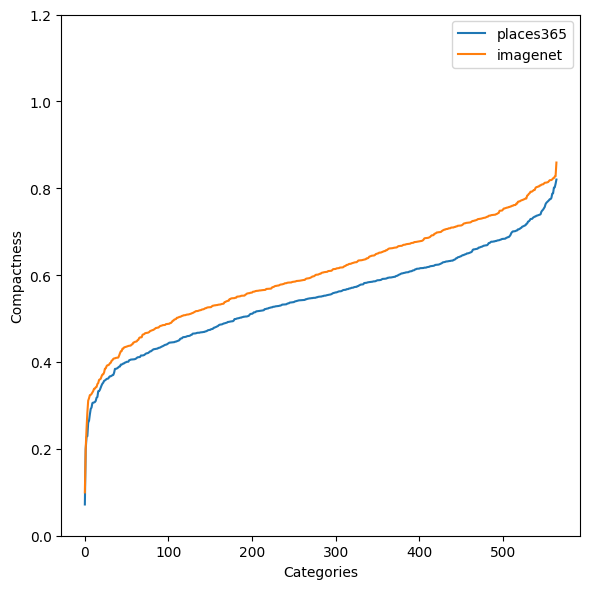

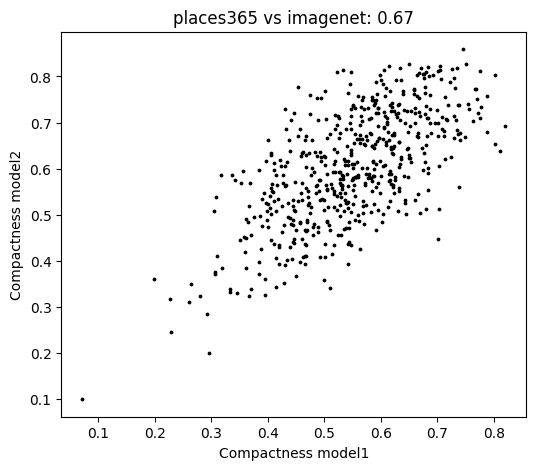

In [16]:
### Path 2 figures
rootsavedir = f'figures/{model1}_{model2}/'

### Load and analyze compactness


compactness = np.load(join(savedir, 'compactness.npy'), allow_pickle=True).item()
sorted_compactness = np.load(join(savedir, 'sorted_compactness.npy'), allow_pickle=True).item()
sorted_compact_categories = np.load(join(savedir, 'sorted_compact_categories.npy'), allow_pickle=True).item()

### Plot sorted compactness
fig_compactness, ax_compactness = max_rsa.plot_stats_one(sorted_compactness,models,  ['Categories', 'Compactness'])

#### Compute correlations between the model's compactness
fig, subs = plt.subplots(1,1, figsize = (6, 5))
subs.scatter(compactness[model1], compactness[model2], color = 'k', s = 3)
corr = np.round(np.corrcoef(compactness[model1], compactness[model2])[0,1], 2)
subs.set_title(f'{model1} vs {model2}: {corr}')
subs.set_xlabel('Compactness model1')
subs.set_ylabel('Compactness model2')
plt.show()
plt.savefig(f'{rootsavedir}/correlation_compactness.png')
plt.close()


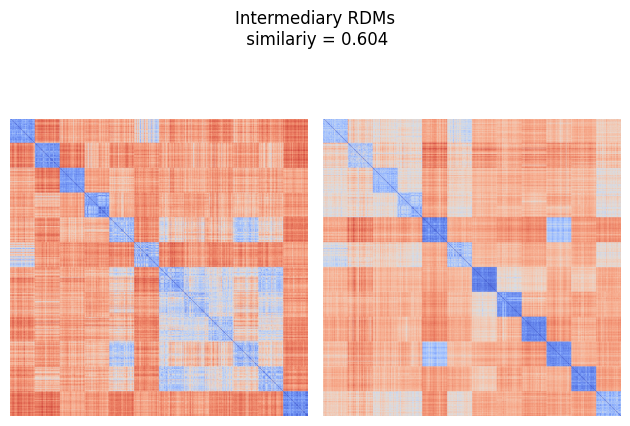

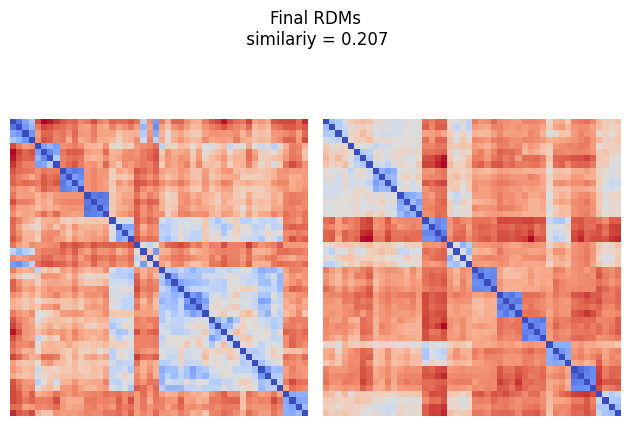

In [25]:
### Load RDMs and display
path2results = f'results/{model1}_{model2}/'

catRDM1 = np.load(join(path2results, f'catRDM_{model1}.npy'))
catRDM2 = np.load(join(path2results, f'catRDM_{model2}.npy'))

RDM1 = np.load(join(path2results, f'RDM_{model1}.npy'))
RDM2 = np.load(join(path2results, f'RDM_{model2}.npy'))

catsim = rsa.Compute_sim_RDMs(catRDM1, catRDM2, metric = 'pearson')
sim = rsa.Compute_sim_RDMs(RDM1, RDM2, metric = 'pearson')

fig, subs = plt.subplots(1,2, sharex=True, sharey=True)
subs[0].imshow(catRDM1, cmap='coolwarm')
subs[1].imshow(catRDM2, cmap='coolwarm')
subs[0].axis('off')
subs[1].axis('off')
fig.suptitle(f'Intermediary RDMs\n similariy = {np.round(catsim,3)}')
fig.tight_layout()
plt.show()
fig.savefig(join(rootsavedir,f'subRDMs/catRDMs.png'))
plt.close()

fig, subs = plt.subplots(1,2, sharex=True, sharey=True)
subs[0].imshow(RDM1, cmap='coolwarm')
subs[1].imshow(RDM2, cmap='coolwarm')
subs[0].axis('off')
subs[1].axis('off')
fig.suptitle(f'Final RDMs\n similariy = {np.round(sim,3)}')
fig.tight_layout()
plt.show()
fig.savefig(join(rootsavedir,f'subRDMs/RDMs.png'))
plt.close()

Running t-SNE on dissimilarity matrix...


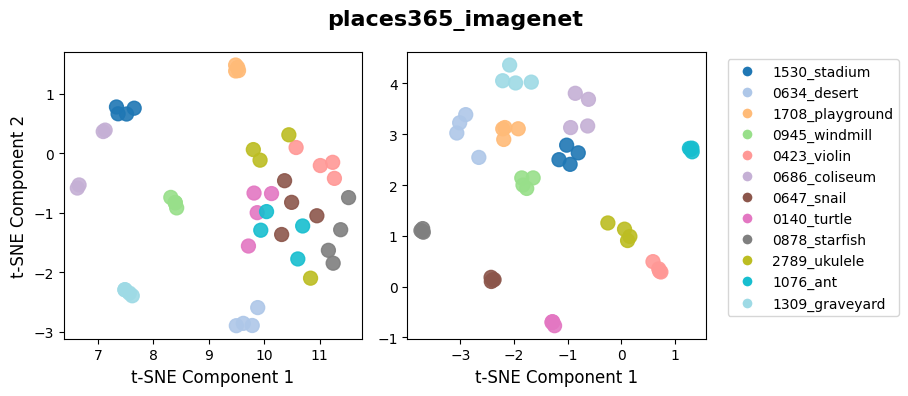

In [53]:
import lib.visualization_sim as vis
importlib.reload(vis)
import json

name = f'{model1}_{model2}'
listimages = json.load(open(join(f'results/{name}', 'stimulipaths.json')))

labels = np.array([im.split('/')[2] for im in listimages])

tsne_results, labels, fig = vis.model_comparison_tsne_pipeline(RDM1,RDM2, labels, name)
#fig.savefig(join(rootsavedir, f'results/{name}/tSNE/final.png'))